# 課題1

データに対して，予測に寄与しない乱数（例えば，ガウス分布に従うノイズ）を加え，変数の重要度がどのように変化するか確認してください．


In [3]:
from xgboost import XGBClassifier
from sklearn.datasets import fetch_openml  # データセットのダウンロード取得用
import pandas as pd  # データフレーム操作用
import numpy as np
import matplotlib.pyplot as plt  # グラフ描画用

In [40]:
# 1. データセットの取得
dataset = fetch_openml("pima-indians-diabetes", version=1, as_frame=True)  # Pimaデータセットを取得
# こんな感じのデータです．8変数の説明変数．Outcomeは0 or 1
dataset.frame.head()  # データフレームの最初の5行を表示

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [41]:
# ノイズの追加
df1 = dataset.frame
np.random.seed(42)
df1["Noise"] = np.random.normal(0,1,size=df1.shape[0])
df1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Noise
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0,0.496714
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0,-0.138264
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0,0.647689
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0,1.523030
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,-0.234153


In [23]:
# 1.1 参考までに相関行列を表示
corr = df1.corr()
# 相関行列をヒートマップで表示．有効数字2桁
corr.style.format(precision=2).background_gradient(cmap="coolwarm")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Noise
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22,0.00
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47,0.01
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07,0.11
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07,0.04
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13,-0.01
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29,0.07
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17,0.00
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24,-0.01
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00,0.01
Noise,0.00,0.01,0.11,0.04,-0.01,0.07,0.00,-0.01,0.01,1.00


In [24]:
# 2. 説明変数をX，目的変数をyに分ける
X = df1.drop(columns=["Outcome"])  # Outcome列を除外
y = df1["Outcome"].astype(int)  # Outcome列を抽出 & 整数型に変換

In [25]:
# 3. 訓練データとテストデータに分割
from sklearn.model_selection import train_test_split  # データ分割用
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)  # 80%訓練，20%テスト

In [26]:
# 4. xgboostを使って学習
model = XGBClassifier(
    n_estimators=100,  # 木の数
    max_depth=3,  # 木の深さ
    learning_rate=0.1,  # 学習率
    random_state=100,  # 再現性のための乱数シード
)
model.fit(X_train, y_train)  # 訓練データで学習


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=100, ...)

In [27]:
# 5. テストデータで予測
y_pred = model.predict(X_test)  # 予測
# 6. 精度を評価
from sklearn.metrics import accuracy_score  # 精度評価用
accuracy = accuracy_score(y_test, y_pred)  # 精度計算
print(f"Accuracy: {accuracy:.3f}")  # 精度を表示(小数点以下3桁)

Accuracy: 0.766


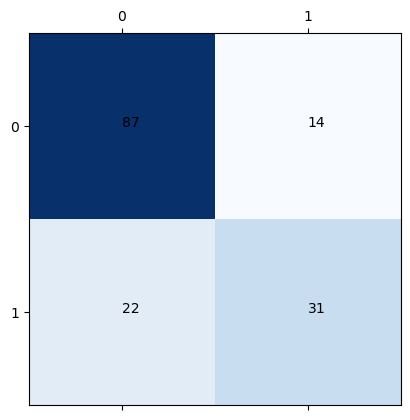

In [28]:
# 7. 混同行列を表示
from sklearn.metrics import confusion_matrix  # 混同行列用
cm = confusion_matrix(y_test, y_pred)  # 混同行列を計算
plt.matshow(cm, cmap="Blues")  # 混同行列をヒートマップで表示
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(x=j, y=i, s=cm[i, j])

Text(0, 0.5, 'Feature')

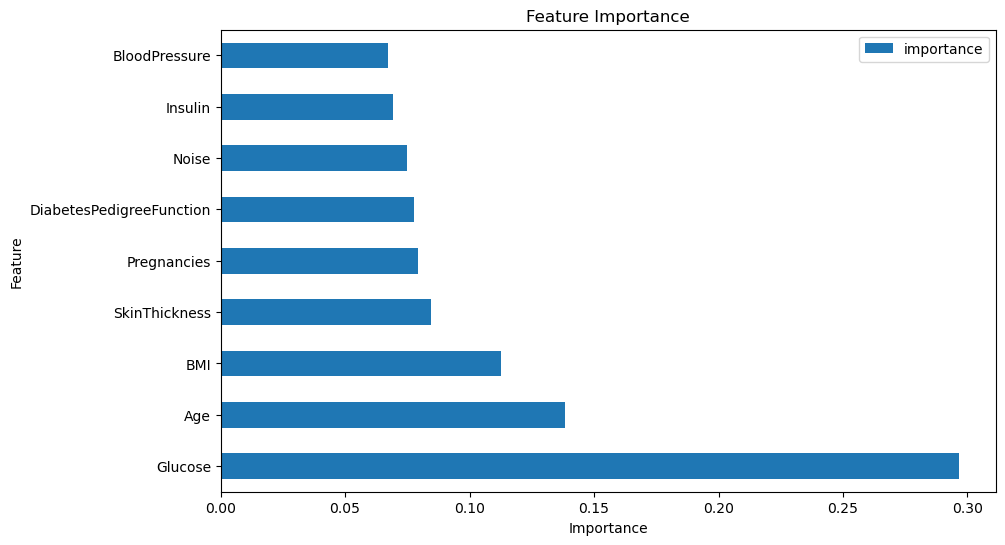

In [29]:
# 8. 特徴量の重要度を表示
importances = model.feature_importances_  # 特徴量の重要度を取得
# 特徴量の重要度をデータフレームに変換
importance_df = pd.DataFrame(
    {
        "feature": X.columns,  # 特徴量名
        "importance": importances,  # 特徴量の重要度
    }
)
importance_df = importance_df.sort_values(by="importance", ascending=False)  # 重要度でソート
# 特徴量の重要度を棒グラフで表示
importance_df.plot(
    kind="barh",  # 横棒グラフ
    x="feature",  # x軸は特徴量名
    y="importance",  # y軸は重要度
    title="Feature Importance",  # タイトル
    figsize=(10, 6),  # サイズ
)
plt.xlabel("Importance")  # x軸ラベル
plt.ylabel("Feature")  # y軸ラベル

ノイズがモデルに効果を与えてしまっている

# 課題2

データに対して，“Glucose”と非常によく似た特徴（例えば，Glucoseに分散5程度のガウス分布に従うノイズを加えた変数）を加え，変数の重要度がどのように変化するか確認してください．

In [42]:
# ノイズの追加
df2 = dataset.frame
np.random.seed(42)
df2["Noise"] = df2["Glucose"] + np.random.normal(0,scale=np.sqrt(5),size=df1.shape[0])
df2.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Noise
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0,149.110687
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0,84.690832
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0,184.448276
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0,92.405598
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,136.476417


In [31]:
# 1.1 参考までに相関行列を表示
corr = df2.corr()
# 相関行列をヒートマップで表示．有効数字2桁
corr.style.format(precision=2).background_gradient(cmap="coolwarm")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Noise
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22,0.13
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47,1.00
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07,0.16
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07,0.06
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13,0.33
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29,0.23
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17,0.14
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24,0.26
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00,0.47
Noise,0.13,1.00,0.16,0.06,0.33,0.23,0.14,0.26,0.47,1.00


In [32]:
# 2. 説明変数をX，目的変数をyに分ける
X = df2.drop(columns=["Outcome"])  # Outcome列を除外
y = df2["Outcome"].astype(int)  # Outcome列を抽出 & 整数型に変換

In [33]:
# 3. 訓練データとテストデータに分割
from sklearn.model_selection import train_test_split  # データ分割用
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)  # 80%訓練，20%テスト

In [34]:
# 4. xgboostを使って学習
model = XGBClassifier(
    n_estimators=100,  # 木の数
    max_depth=3,  # 木の深さ
    learning_rate=0.1,  # 学習率
    random_state=100,  # 再現性のための乱数シード
)
model.fit(X_train, y_train)  # 訓練データで学習

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=100, ...)

In [35]:
# 5. テストデータで予測
y_pred = model.predict(X_test)  # 予測
# 6. 精度を評価
from sklearn.metrics import accuracy_score  # 精度評価用
accuracy = accuracy_score(y_test, y_pred)  # 精度計算
print(f"Accuracy: {accuracy:.3f}")  # 精度を表示(小数点以下3桁)

Accuracy: 0.760


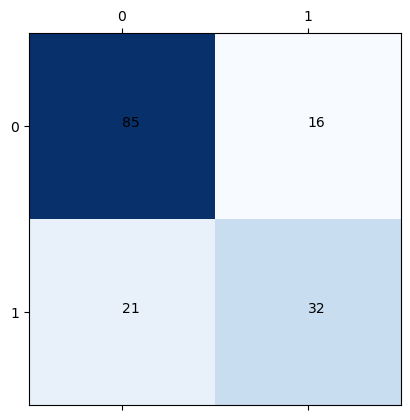

In [36]:
# 7. 混同行列を表示
from sklearn.metrics import confusion_matrix  # 混同行列用
cm = confusion_matrix(y_test, y_pred)  # 混同行列を計算
plt.matshow(cm, cmap="Blues")  # 混同行列をヒートマップで表示
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(x=j, y=i, s=cm[i, j])

Text(0, 0.5, 'Feature')

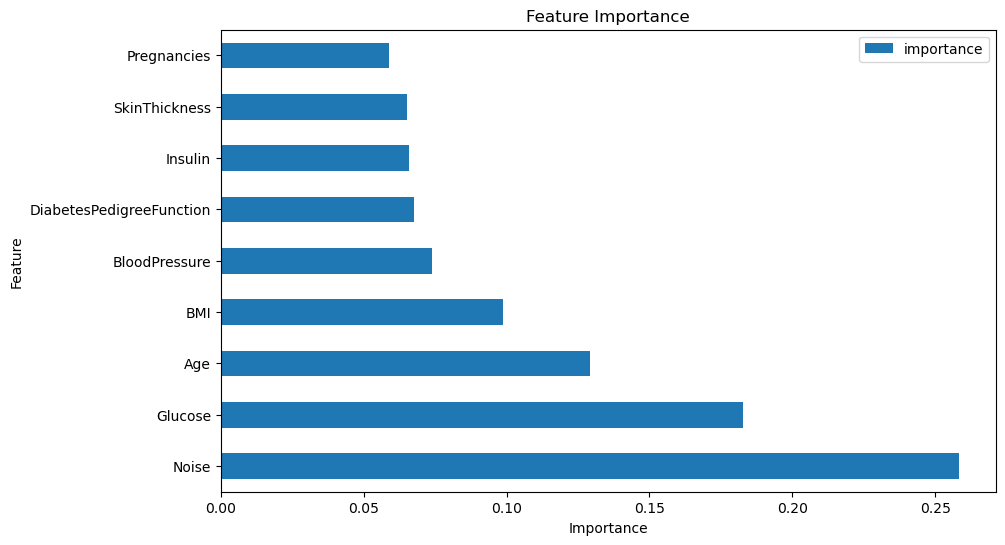

In [37]:
# 8. 特徴量の重要度を表示
importances = model.feature_importances_  # 特徴量の重要度を取得
# 特徴量の重要度をデータフレームに変換
importance_df = pd.DataFrame(
    {
        "feature": X.columns,  # 特徴量名
        "importance": importances,  # 特徴量の重要度
    }
)
importance_df = importance_df.sort_values(by="importance", ascending=False)  # 重要度でソート
# 特徴量の重要度を棒グラフで表示
importance_df.plot(
    kind="barh",  # 横棒グラフ
    x="feature",  # x軸は特徴量名
    y="importance",  # y軸は重要度
    title="Feature Importance",  # タイトル
    figsize=(10, 6),  # サイズ
)
plt.xlabel("Importance")  # x軸ラベル
plt.ylabel("Feature")  # y軸ラベル

ノイズの重要度が最も大きくなってしまっている

# 課題3

さらに， “Glucose”と非常によく似た特徴を（10個程度）増やした場合に変数の重要度がどのように変化するか確認してください．

In [43]:
# ノイズの追加
df3 = dataset.frame
np.random.seed(42)
for i in range(10):
    noise = np.random.normal(loc=0, scale=np.sqrt(5), size=X.shape[0])
    df3[f"Noise_{i+1}"] = df3["Glucose"] + noise
df3.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Noise,Noise_1,Noise_2,Noise_3,Noise_4,Noise_5,Noise_6,Noise_7,Noise_8,Noise_9,Noise_10
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0,149.110687,149.110687,146.598059,149.148445,152.462448,148.452421,146.626332,149.534733,153.751156,149.320944,146.464853
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0,84.690832,84.690832,89.052758,83.808845,91.953989,88.648943,83.412864,83.124179,79.970116,84.507811,87.601388
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0,184.448276,184.448276,184.582581,180.383986,184.356674,181.360888,185.188864,183.151692,184.361174,183.142324,185.389892
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0,92.405598,92.405598,87.742286,82.577426,88.590360,93.065310,85.932689,84.483305,87.754218,88.168677,86.124417
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,136.476417,136.476417,138.414107,136.938475,138.195191,138.733300,140.597343,140.224287,135.688736,133.695958,134.566238


In [45]:
# 1.1 参考までに相関行列を表示
corr = df3.corr()
# 相関行列をヒートマップで表示．有効数字2桁
corr.style.format(precision=2).background_gradient(cmap="coolwarm")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Noise,Noise_1,Noise_2,Noise_3,Noise_4,Noise_5,Noise_6,Noise_7,Noise_8,Noise_9,Noise_10
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22,0.13,0.13,0.13,0.13,0.13,0.13,0.13,0.13,0.13,0.13,0.13
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07,0.16,0.16,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.16,0.15
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07,0.06,0.06,0.06,0.05,0.06,0.06,0.05,0.06,0.06,0.06,0.06
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13,0.33,0.33,0.33,0.33,0.33,0.33,0.33,0.33,0.33,0.33,0.33
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29,0.23,0.23,0.22,0.22,0.22,0.22,0.22,0.23,0.22,0.22,0.22
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17,0.14,0.14,0.14,0.13,0.14,0.14,0.14,0.14,0.14,0.14,0.14
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24,0.26,0.26,0.26,0.26,0.26,0.26,0.26,0.26,0.26,0.26,0.26
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00,0.47,0.47,0.46,0.47,0.46,0.47,0.47,0.46,0.47,0.46,0.46
Noise,0.13,1.00,0.16,0.06,0.33,0.23,0.14,0.26,0.47,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.99


In [46]:
# 2. 説明変数をX，目的変数をyに分ける
X = df3.drop(columns=["Outcome"])  # Outcome列を除外
y = df3["Outcome"].astype(int)  # Outcome列を抽出 & 整数型に変換

In [47]:
# 3. 訓練データとテストデータに分割
from sklearn.model_selection import train_test_split  # データ分割用
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)  # 80%訓練，20%テスト

In [48]:
# 4. xgboostを使って学習
model = XGBClassifier(
    n_estimators=100,  # 木の数
    max_depth=3,  # 木の深さ
    learning_rate=0.1,  # 学習率
    random_state=100,  # 再現性のための乱数シード
)
model.fit(X_train, y_train)  # 訓練データで学習

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=100, ...)

In [49]:
# 5. テストデータで予測
y_pred = model.predict(X_test)  # 予測
# 6. 精度を評価
from sklearn.metrics import accuracy_score  # 精度評価用
accuracy = accuracy_score(y_test, y_pred)  # 精度計算
print(f"Accuracy: {accuracy:.3f}")  # 精度を表示(小数点以下3桁)

Accuracy: 0.773


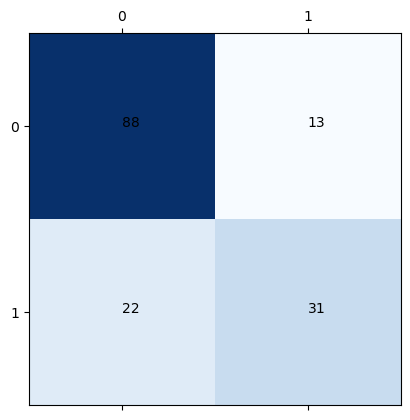

In [50]:
# 7. 混同行列を表示
from sklearn.metrics import confusion_matrix  # 混同行列用
cm = confusion_matrix(y_test, y_pred)  # 混同行列を計算
plt.matshow(cm, cmap="Blues")  # 混同行列をヒートマップで表示
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(x=j, y=i, s=cm[i, j])

Text(0, 0.5, 'Feature')

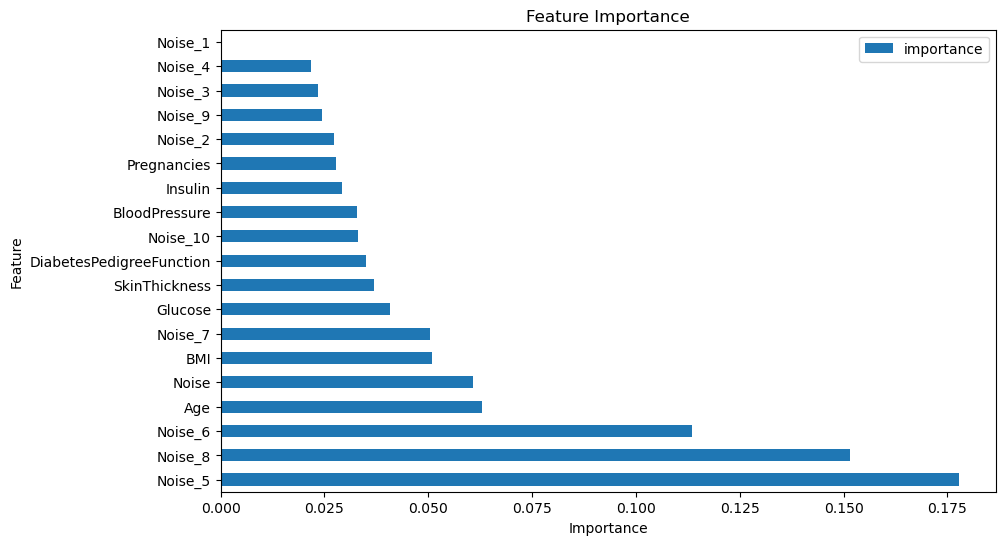

In [51]:
# 8. 特徴量の重要度を表示
importances = model.feature_importances_  # 特徴量の重要度を取得
# 特徴量の重要度をデータフレームに変換
importance_df = pd.DataFrame(
    {
        "feature": X.columns,  # 特徴量名
        "importance": importances,  # 特徴量の重要度
    }
)
importance_df = importance_df.sort_values(by="importance", ascending=False)  # 重要度でソート
# 特徴量の重要度を棒グラフで表示
importance_df.plot(
    kind="barh",  # 横棒グラフ
    x="feature",  # x軸は特徴量名
    y="importance",  # y軸は重要度
    title="Feature Importance",  # タイトル
    figsize=(10, 6),  # サイズ
)
plt.xlabel("Importance")  # x軸ラベル
plt.ylabel("Feature")  # y軸ラベル

一部のノイズは無視できているが、半数程は重要度が高くなっている

# 課題4

一つの変数を連続値ではなくカテゴリ値に変更した場合に変数の重要度がどのように変化するか確認してください．

In [57]:
# ノイズの追加
dataset = fetch_openml("pima-indians-diabetes", version=1, as_frame=True)
df4 = dataset.frame
np.random.seed(42)
df4["BMI"] = pd.cut(df4["BMI"], bins=4, labels=["low", "mid_low", "mid_high", "high"])
df4 = pd.get_dummies(df4, dtype=int)
df4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age,Outcome,BMI_low,BMI_mid_low,BMI_mid_high,BMI_high
0,6.0,148.0,72.0,35.0,0.0,0.627,50.0,1.0,0,0,1,0
1,1.0,85.0,66.0,29.0,0.0,0.351,31.0,0.0,0,1,0,0
2,8.0,183.0,64.0,0.0,0.0,0.672,32.0,1.0,0,1,0,0
3,1.0,89.0,66.0,23.0,94.0,0.167,21.0,0.0,0,1,0,0
4,0.0,137.0,40.0,35.0,168.0,2.288,33.0,1.0,0,0,1,0


In [59]:
# 1.1 参考までに相関行列を表示
corr = df4.corr()
# 相関行列をヒートマップで表示．有効数字2桁
corr.style.format(precision=2).background_gradient(cmap="coolwarm")

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age,Outcome,BMI_low,BMI_mid_low,BMI_mid_high,BMI_high
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,-0.03,0.54,0.22,0.00,-0.02,0.03,-0.04
Glucose,0.13,1.00,0.15,0.06,0.33,0.14,0.26,0.47,-0.06,-0.17,0.17,0.05
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.04,0.24,0.07,-0.25,-0.11,0.17,0.02
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.18,-0.11,0.07,-0.12,-0.34,0.35,0.09
Insulin,-0.07,0.33,0.09,0.44,1.00,0.19,-0.04,0.13,-0.08,-0.18,0.18,0.07
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,1.00,0.03,0.17,-0.01,-0.10,0.08,0.09
Age,0.54,0.26,0.24,-0.11,-0.04,0.03,1.00,0.24,-0.03,-0.04,0.06,-0.06
Outcome,0.22,0.47,0.07,0.07,0.13,0.17,0.24,1.00,-0.04,-0.21,0.21,0.09
BMI_low,0.00,-0.06,-0.25,-0.12,-0.08,-0.01,-0.03,-0.04,1.00,-0.14,-0.10,-0.01
BMI_mid_low,-0.02,-0.17,-0.11,-0.34,-0.18,-0.10,-0.04,-0.21,-0.14,1.00,-0.95,-0.12


In [60]:
# 2. 説明変数をX，目的変数をyに分ける
X = df4.drop(columns=["Outcome"])  # Outcome列を除外
y = df4["Outcome"].astype(int)  # Outcome列を抽出 & 整数型に変換

In [61]:
# 3. 訓練データとテストデータに分割
from sklearn.model_selection import train_test_split  # データ分割用
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=500)  # 80%訓練，20%テスト

In [62]:
# 4. xgboostを使って学習
model = XGBClassifier(
    n_estimators=100,  # 木の数
    max_depth=3,  # 木の深さ
    learning_rate=0.1,  # 学習率
    random_state=100,  # 再現性のための乱数シード
)
model.fit(X_train, y_train)  # 訓練データで学習

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=100, ...)

In [63]:
# 5. テストデータで予測
y_pred = model.predict(X_test)  # 予測
# 6. 精度を評価
from sklearn.metrics import accuracy_score  # 精度評価用
accuracy = accuracy_score(y_test, y_pred)  # 精度計算
print(f"Accuracy: {accuracy:.3f}")  # 精度を表示(小数点以下3桁)

Accuracy: 0.740


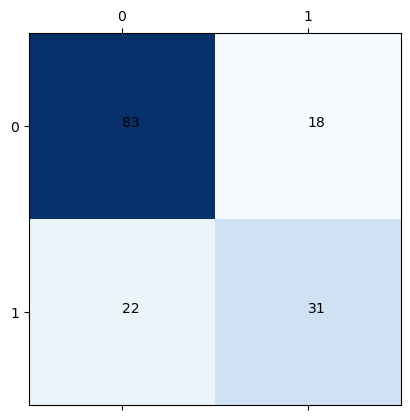

In [64]:
# 7. 混同行列を表示
from sklearn.metrics import confusion_matrix  # 混同行列用
cm = confusion_matrix(y_test, y_pred)  # 混同行列を計算
plt.matshow(cm, cmap="Blues")  # 混同行列をヒートマップで表示
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(x=j, y=i, s=cm[i, j])

Text(0, 0.5, 'Feature')

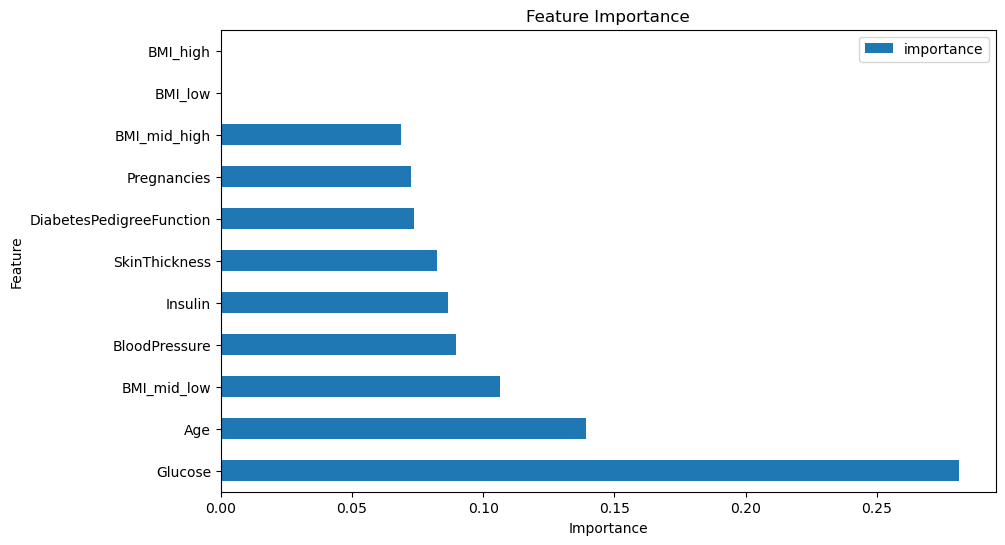

In [65]:
# 8. 特徴量の重要度を表示
importances = model.feature_importances_  # 特徴量の重要度を取得
# 特徴量の重要度をデータフレームに変換
importance_df = pd.DataFrame(
    {
        "feature": X.columns,  # 特徴量名
        "importance": importances,  # 特徴量の重要度
    }
)
importance_df = importance_df.sort_values(by="importance", ascending=False)  # 重要度でソート
# 特徴量の重要度を棒グラフで表示
importance_df.plot(
    kind="barh",  # 横棒グラフ
    x="feature",  # x軸は特徴量名
    y="importance",  # y軸は重要度
    title="Feature Importance",  # タイトル
    figsize=(10, 6),  # サイズ
)
plt.xlabel("Importance")  # x軸ラベル
plt.ylabel("Feature")  # y軸ラベル

一つのダミー変数が高くなっており、他の関連するダミー変数は低くなっている